In [2]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("train.csv")

In [75]:
df = df[df['Fuel_Type'] != 'Electric']
df = df.reset_index(drop=True)

print("Voitures électriques supprimées.")
print("Nombre de lignes restantes :", len(df))



Voitures électriques supprimées.
Nombre de lignes restantes : 6017


In [4]:
df_copy = df.copy()

In [5]:
df_copy.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [7]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 611.4+ KB


In [11]:
stats=df_copy.describe()
print(stats)
df_copy.describe(include='all')

              Year  Kilometers_Driven        Seats        Price
count  6019.000000       6.019000e+03  5977.000000  6019.000000
mean   2013.358199       5.873838e+04     5.278735     9.479468
std       3.269742       9.126884e+04     0.808840    11.187917
min    1998.000000       1.710000e+02     0.000000     0.440000
25%    2011.000000       3.400000e+04     5.000000     3.500000
50%    2014.000000       5.300000e+04     5.000000     5.640000
75%    2016.000000       7.300000e+04     5.000000     9.950000
max    2019.000000       6.500000e+06    10.000000   160.000000


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
count,6019,6019,6019.000000,6.019000e+03,6019,6019,6019,6017,5983,5983,5977.000000,824,6019.000000
unique,1876,11,NaN,NaN,5,2,4,442,146,372,NaN,540,NaN
top,Mahindra XUV500 W8 2WD,Mumbai,NaN,NaN,Diesel,Manual,First,18.9 kmpl,1197 CC,74 bhp,NaN,95.13 Lakh,NaN
freq,49,790,NaN,NaN,3205,4299,4929,172,606,235,NaN,6,NaN
mean,NaN,NaN,2013.358199,5.873838e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.278735,NaN,9.479468
std,NaN,NaN,3.269742,9.126884e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.808840,NaN,11.187917
min,NaN,NaN,1998.000000,1.710000e+02,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.440000
25%,NaN,NaN,2011.000000,3.400000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,3.500000
50%,NaN,NaN,2014.000000,5.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,5.640000
75%,NaN,NaN,2016.000000,7.300000e+04,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,9.950000


In [19]:
df_copy.sample(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
1118,Volkswagen Polo 1.5 TDI Highline,Hyderabad,2014,69000,Diesel,Manual,First,20.14 kmpl,1498 CC,88.8 bhp,5.0,NaN,5.19
1135,Maruti Zen Estilo LXI Green (CNG),Ahmedabad,2011,76000,CNG,Manual,First,26.3 km/kg,998 CC,67.1 bhp,5.0,NaN,2.00
1635,Volkswagen Passat Diesel Highline 2.0 TDI,Kolkata,2012,72000,Diesel,Automatic,First,18.33 kmpl,1968 CC,167.7 bhp,5.0,NaN,6.00
5123,Hyundai Grand i10 Magna,Delhi,2014,31200,Petrol,Manual,First,18.9 kmpl,1197 CC,82 bhp,5.0,NaN,3.90
5931,Maruti Ertiga VXI,Mumbai,2012,52500,Petrol,Manual,Second,16.02 kmpl,1373 CC,93.7 bhp,7.0,NaN,5.25


Data cleaning

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 611.4+ KB


In [22]:
isnull=df_copy.isnull().sum()
print(isnull)

Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64


In [23]:
df_copy.duplicated().sum()

np.int64(0)

In [24]:
df_copy.drop('New_Price', axis=1, inplace=True) 

In [27]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 564.4+ KB


In [ ]:
df_copy.dropna(inplace=True)

In [40]:
df_copy[df_copy['Power'] == 'null bhp']

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
76,Ford Fiesta 1.4 SXi TDCi,Jaipur,2008,111111,Diesel,Manual,First,17.8 kmpl,1399 CC,null bhp,5.0,2.00
79,Hyundai Santro Xing XL,Hyderabad,2005,87591,Petrol,Manual,First,0.0 kmpl,1086 CC,null bhp,5.0,1.30
89,Hyundai Santro Xing XO,Hyderabad,2007,73745,Petrol,Manual,First,17.0 kmpl,1086 CC,null bhp,5.0,2.10
120,Hyundai Santro Xing XL eRLX Euro III,Mumbai,2005,102000,Petrol,Manual,Second,17.0 kmpl,1086 CC,null bhp,5.0,0.85
143,Hyundai Santro Xing XO eRLX Euro II,Kochi,2008,80759,Petrol,Manual,Third,17.0 kmpl,1086 CC,null bhp,5.0,1.67
...,...,...,...,...,...,...,...,...,...,...,...,...
5873,Hyundai Santro Xing XO eRLX Euro II,Pune,2006,47200,Petrol,Manual,Second,17.0 kmpl,1086 CC,null bhp,5.0,1.20
5893,Maruti Estilo LXI,Chennai,2008,51000,Petrol,Manual,Second,19.5 kmpl,1061 CC,null bhp,NaN,1.75
5925,Skoda Laura Classic 1.8 TSI,Pune,2010,85000,Petrol,Manual,First,17.5 kmpl,1798 CC,null bhp,5.0,2.85
5943,Mahindra Jeep MM 540 DP,Chennai,2002,75000,Diesel,Manual,First,0.0 kmpl,2112 CC,null bhp,6.0,1.70


In [43]:
dirty_cols = ['Mileage', 'Engine', 'Power']

In [49]:
for col in dirty_cols:
    df_copy[col] = (
        df_copy[col]
        .astype(str)
        .str.split()
        .str[0]
        .replace("null", pd.NA)
        .pipe(pd.to_numeric, errors="coerce")
    )

In [50]:
df_copy.sample(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
3682,Maruti Ignis 1.2 Delta,Kochi,2019,12076,Petrol,Manual,First,20.89,1197.0,81.80,5.0,5.50
2791,Renault Fluence Diesel E4,Delhi,2012,87510,Diesel,Manual,First,21.80,1461.0,78.00,5.0,3.49
4705,Maruti Alto 800 VXI,Coimbatore,2016,18043,Petrol,Manual,First,22.74,796.0,47.30,5.0,4.12
2461,Nissan Terrano XV 110 PS,Mumbai,2015,54000,Diesel,Manual,Second,19.01,1461.0,108.50,5.0,6.00
487,Hyundai Verna 1.6 SX,Kolkata,2013,37873,Diesel,Manual,First,22.32,1582.0,126.32,5.0,4.80


In [53]:
df_copy['Name'] = df_copy['Name'].str.upper()
df_copy.sample(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
1336,AUDI Q7 45 TDI QUATTRO TECHNOLOGY,Mumbai,2016,20002,Diesel,Automatic,First,14.75,2967.0,245.00,7.0,67.00
5201,MAHINDRA SCORPIO SLE BSIV,Bangalore,2013,70359,Diesel,Manual,First,12.05,2179.0,120.00,8.0,7.65
1459,MARUTI SWIFT DZIRE TOUR LDI,Delhi,2014,71800,Diesel,Manual,First,23.40,1248.0,74.00,5.0,2.90
3698,MARUTI SX4 ZXI MT BSIV,Mumbai,2012,51800,Petrol,Manual,First,15.50,1586.0,103.30,5.0,3.90
4724,HYUNDAI XCENT 1.2 VTVT E,Pune,2018,40000,Petrol,Manual,First,20.14,1197.0,81.86,5.0,5.00


In [55]:
# Séparer Brand et Model
df_copy['Brand'] = df_copy['Name'].str.split().str[0]             # Premier mot
df_copy['Model'] = df_copy['Name'].str.split().str[1:].str.join(' ')  # Le reste
df_copy.sample(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
2924,LAND ROVER RANGE ROVER HSE DYNAMIC,Kochi,2018,41661,Diesel,Automatic,First,12.70,2179.0,187.7,5.0,44.83,LAND,ROVER RANGE ROVER HSE DYNAMIC
2834,MARUTI SWIFT VDI BSIV,Chennai,2015,23000,Diesel,Manual,First,25.20,1248.0,74.0,5.0,6.50,MARUTI,SWIFT VDI BSIV
3286,TATA MANZA AURA QUADRAJET BS IV,Jaipur,2012,79000,Diesel,Manual,First,21.12,1248.0,88.8,5.0,2.59,TATA,MANZA AURA QUADRAJET BS IV
1408,BMW 5 SERIES 523I SEDAN,Mumbai,2010,69300,Petrol,Automatic,Second,10.80,2497.0,150.0,5.0,12.50,BMW,5 SERIES 523I SEDAN
3053,HYUNDAI VERNA CRDI SX ABS,Hyderabad,2008,150000,Diesel,Manual,First,18.10,1493.0,110.0,5.0,3.00,HYUNDAI,VERNA CRDI SX ABS


In [80]:
df_copy["Kilometers_Driven"]
df_copy["Kilometers_Driven"].mean()


np.float64(58738.38029573019)

In [59]:
df_copy.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,MARUTI WAGON R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,MARUTI,WAGON R LXI CNG
1,HYUNDAI CRETA 1.6 CRDI SX OPTION,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION
2,HONDA JAZZ V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,HONDA,JAZZ V
3,MARUTI ERTIGA VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,MARUTI,ERTIGA VDI
4,AUDI A4 NEW 2.0 TDI MULTITRONIC,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC


In [65]:
Price_euros=df_copy["Price"]*0.009292*100000
df_copy['Price_Euros'] = Price_euros
df_copy.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model,Price_Euros
0,MARUTI WAGON R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,MARUTI,WAGON R LXI CNG,1626.100
1,HYUNDAI CRETA 1.6 CRDI SX OPTION,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION,11615.000
2,HONDA JAZZ V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,HONDA,JAZZ V,4181.400
3,MARUTI ERTIGA VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,MARUTI,ERTIGA VDI,5575.200
4,AUDI A4 NEW 2.0 TDI MULTITRONIC,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC,16484.008


Text(0.5, 1.0, 'Matrice de Corrélation')

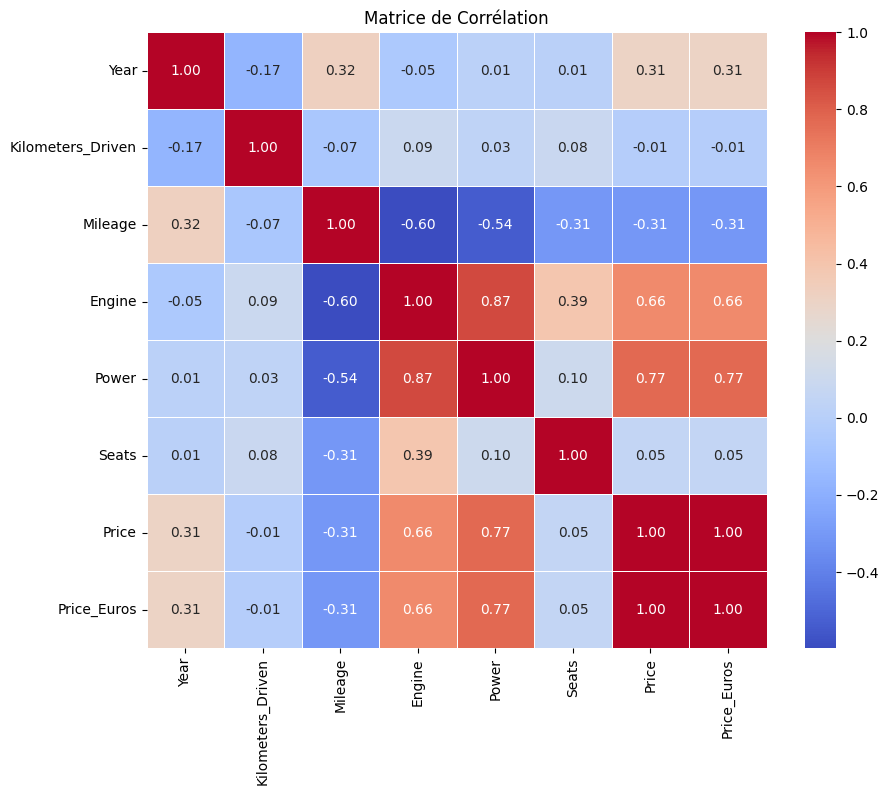

In [76]:
df_num = df_copy.select_dtypes(include=["number"])
corr_matrix = df_num.corr()
corr_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation")

In [86]:
df = pd.read_csv("train_clean.csv")
df.info()
isnull=df.isnull().sum()
print(isnull)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6013 entries, 0 to 6012
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6013 non-null   object 
 1   Year               6013 non-null   int64  
 2   Kilometers_Driven  6013 non-null   int64  
 3   Fuel_Type          6013 non-null   object 
 4   Transmission       6013 non-null   object 
 5   Owner_Type         6013 non-null   object 
 6   Mileage            6013 non-null   float64
 7   Power              6013 non-null   float64
 8   Price              6013 non-null   float64
 9   Brand              6013 non-null   object 
 10  Model              6013 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 516.9+ KB
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Power                0
Price                

In [ ]:
valeurs_uniques_